In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import scipy.cluster.hierarchy as shc
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorboardX import SummaryWriter
import os
import time
from torcheval.metrics import R2Score
from sklearn.metrics import r2_score
import shap

%matplotlib inline
pd.set_option('display.max_columns', None)

In [86]:
class MLP(nn.Module):
    """
        Multilayer Perceptron for regression.
    """

    def __init__(self, n_in, n_out):
        super().__init__()
        #         self.layers = nn.Sequential(
        #             nn.Linear(n_in, 64),
        #             nn.ReLU(),
        #             nn.Linear(64, 32),
        #             nn.ReLU(),
        #             nn.Linear(32, n_out)
        #         )

        #         self.layers = nn.Sequential(
        #             nn.Linear(n_in, 32),
        #             nn.ReLU(),
        #             nn.Linear(32, 64),
        #             nn.ReLU(),
        #             nn.Linear(64, 64),
        #             nn.ReLU(),
        #             nn.Linear(64, 32),
        #             nn.ReLU(),
        #             nn.Linear(32, 16),
        #             nn.ReLU(),
        #             nn.Linear(16, n_out)
        #         )

        self.layers = nn.Sequential(
            nn.Linear(n_in, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, n_out)
        )

    #         self.layers = nn.Sequential(
    #             nn.Linear(n_in, 32),
    #             nn.ReLU(),
    #             nn.Linear(32, 32),
    #             nn.ReLU(),
    #             nn.Linear(32, 32),
    #             nn.ReLU(),
    #             nn.Linear(32, n_out)
    #         )

    def forward(self, x):
        """
          Forward pass
        """
        return self.layers(x)


# Factor 0

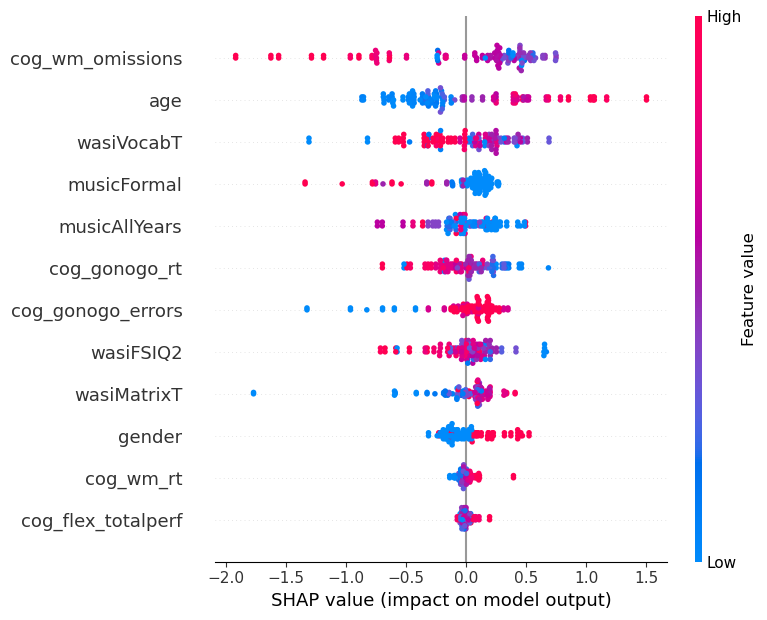

In [87]:
model = MLP(12, 1)
model.load_state_dict(torch.load('results/factor_v1/deep_model_0.mdl'))

df_to_run = pd.read_csv('../data/deep_factor_test_retest_imputed_all_standardized.csv')
data_arr = df_to_run.iloc[:, 2:].to_numpy()
X = data_arr[:, :12]
feature_names = df_to_run.iloc[:, 2:14].columns
X_torch = torch.from_numpy(X).float()

shap.DeepExplainer(model=model, data=X_torch)
shap.initjs() 
explainer = shap.DeepExplainer(model=model, data=X_torch)
shap_values = explainer.shap_values(X_torch)
shap.summary_plot(shap_values, features=X_torch, feature_names=feature_names, title='factor 0') 

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead


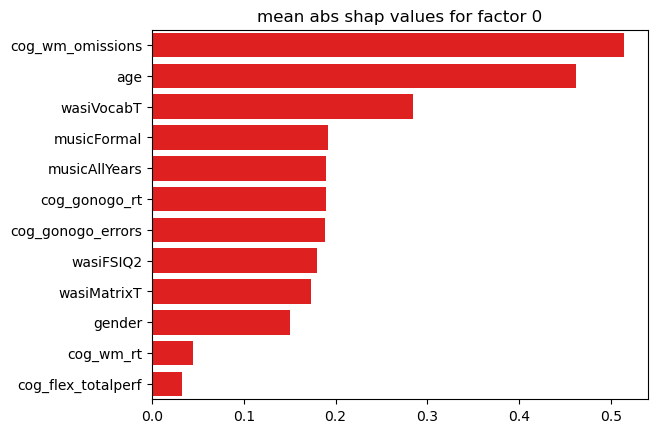

In [88]:
mean_val = np.mean(np.abs(shap_values), axis=0)
g = sns.barplot(y=feature_names,
                x=mean_val, palette=['r'],
                order=feature_names[np.argsort(-mean_val)]
               )
g.set_title('mean abs shap values for factor 0')

name = 'mean_abs_shap_fac0'
g.figure.savefig("results/" + name + ".png") 

Text(0.5, 0.98, 'Factor 0')

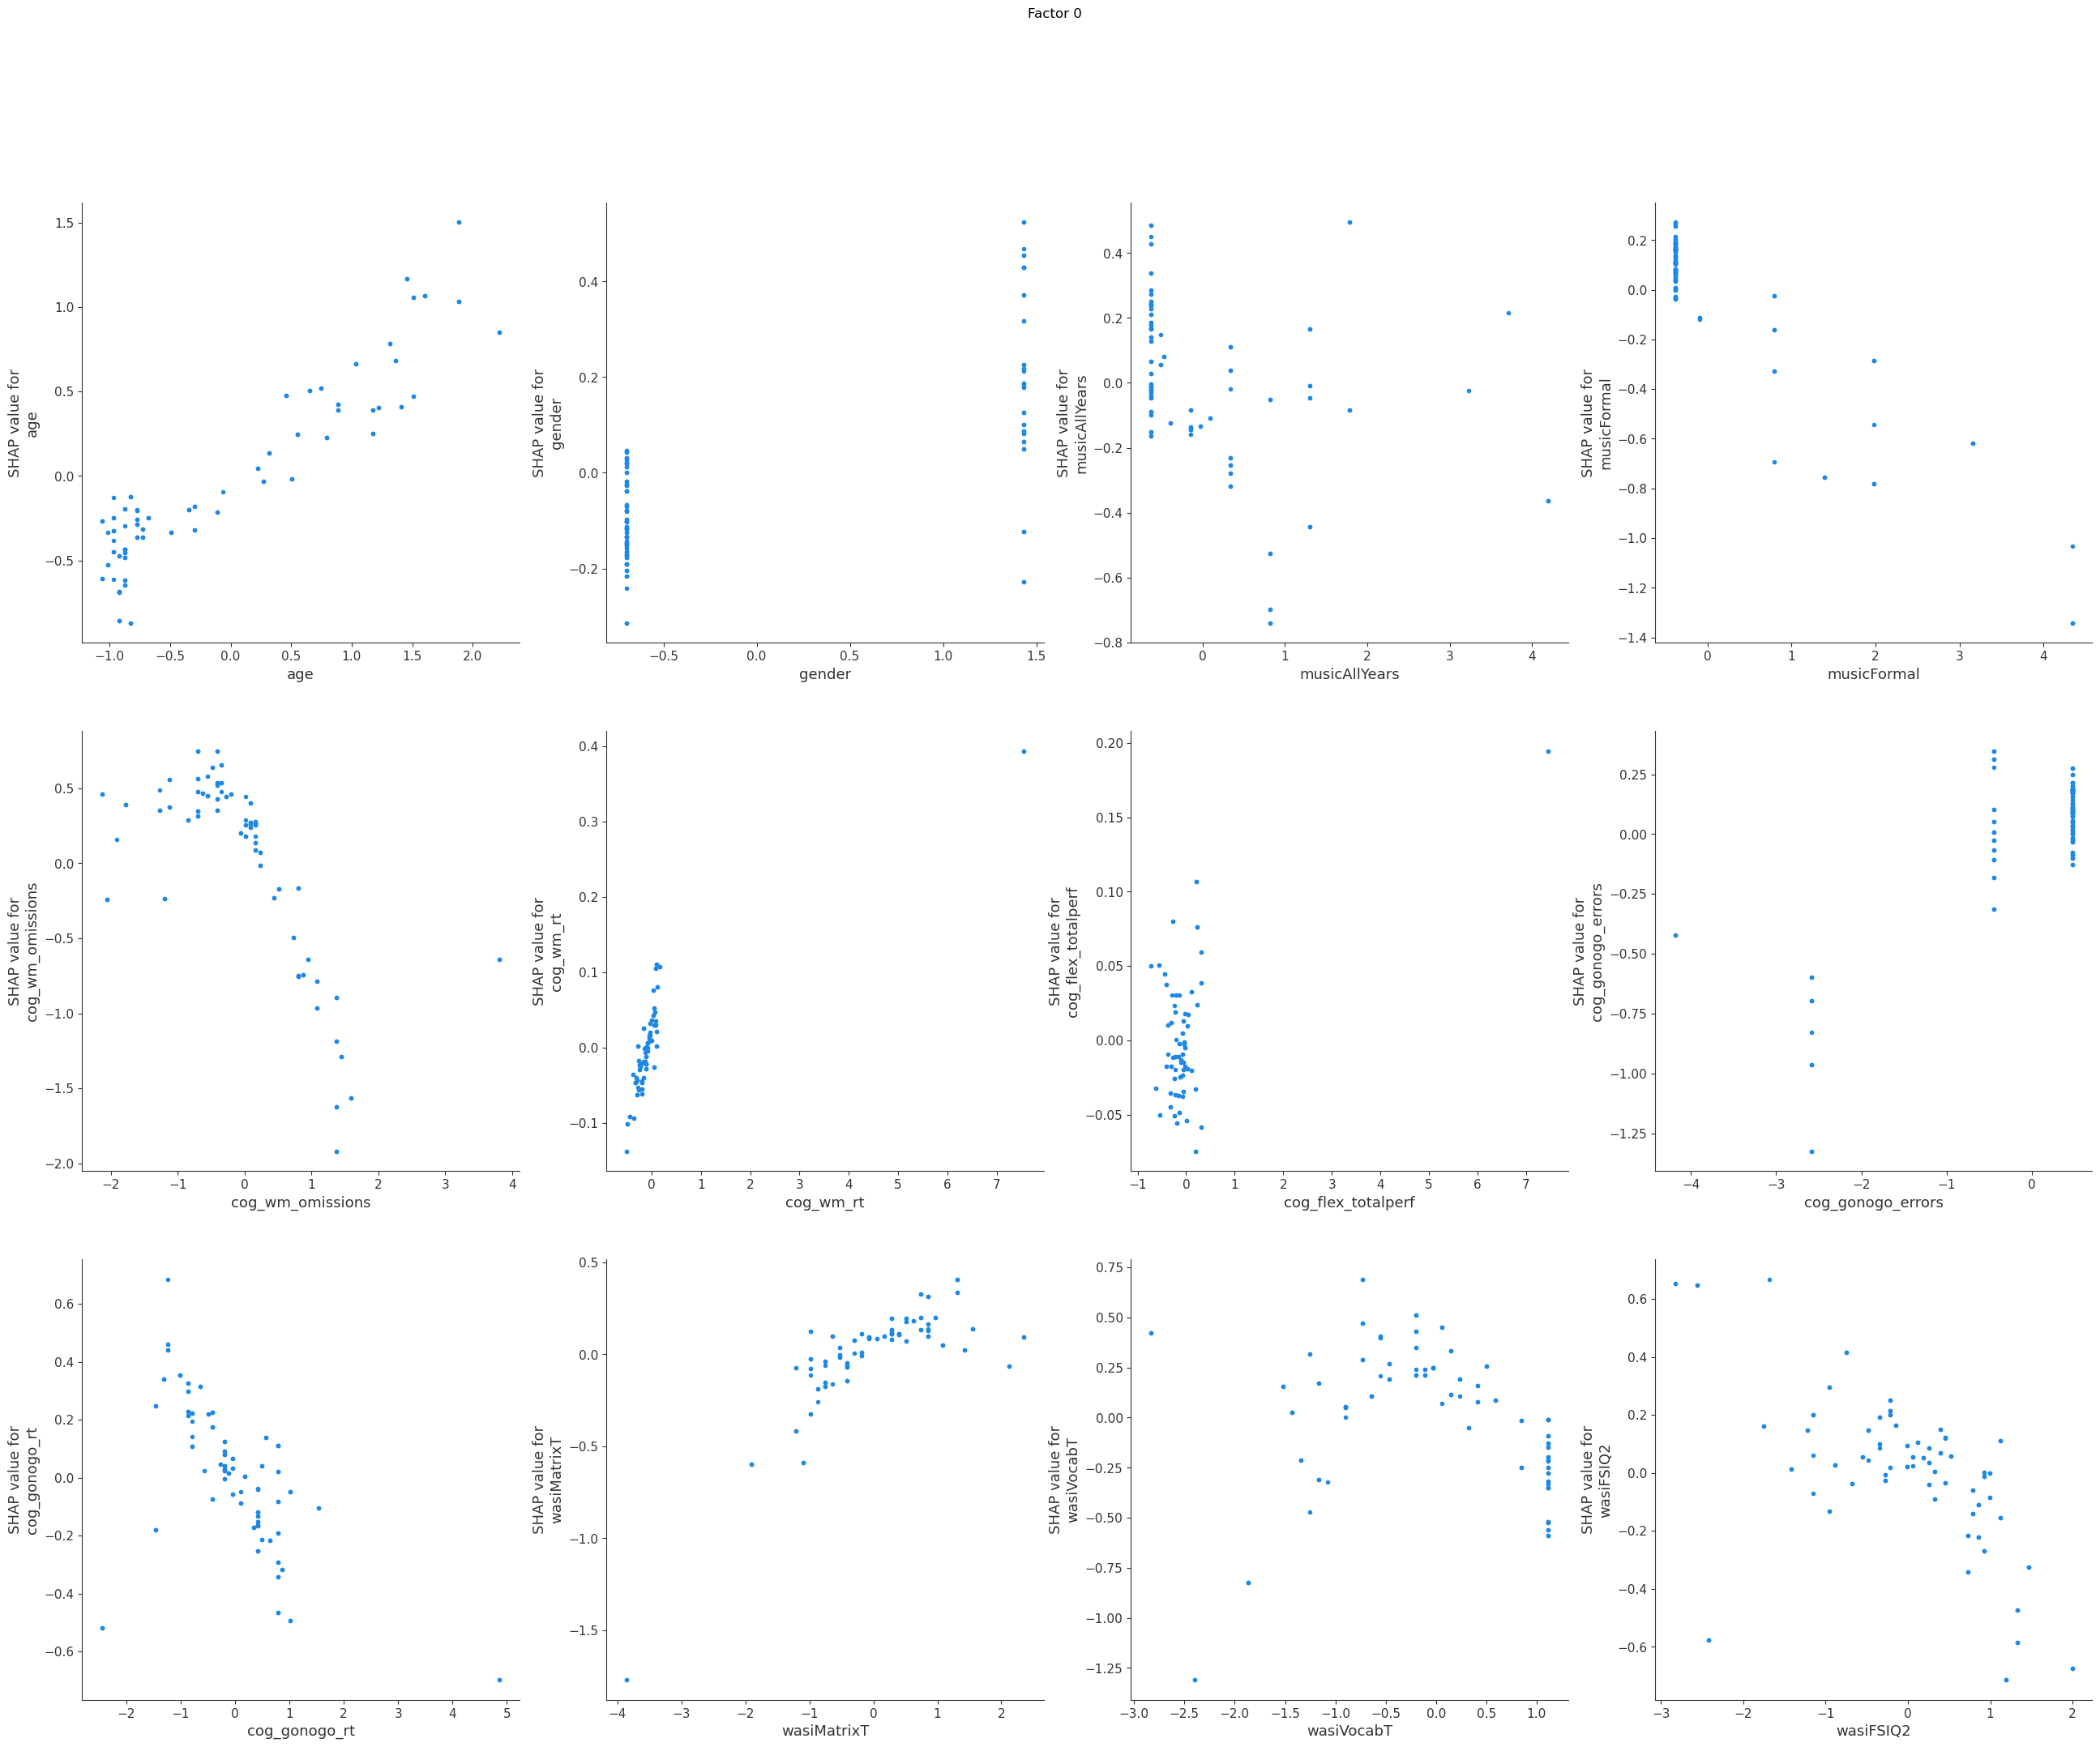

In [89]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(32,24))

shap.dependence_plot(ind=0, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 0], show=False) 

shap.dependence_plot(ind=1, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 1], show=False) 

shap.dependence_plot(ind=2, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 2], show=False) 

shap.dependence_plot(ind=3, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 3], show=False) 

shap.dependence_plot(ind=4, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 0], show=False) 

shap.dependence_plot(ind=5, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 1], show=False) 

shap.dependence_plot(ind=6, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 2], show=False) 

shap.dependence_plot(ind=7, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 3], show=False) 

shap.dependence_plot(ind=8, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 0], show=False) 

shap.dependence_plot(ind=9, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 1], show=False) 

shap.dependence_plot(ind=10, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 2], show=False) 

shap.dependence_plot(ind=11, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 3], show=False) 


fig.suptitle('Factor 0')

# Factor 1

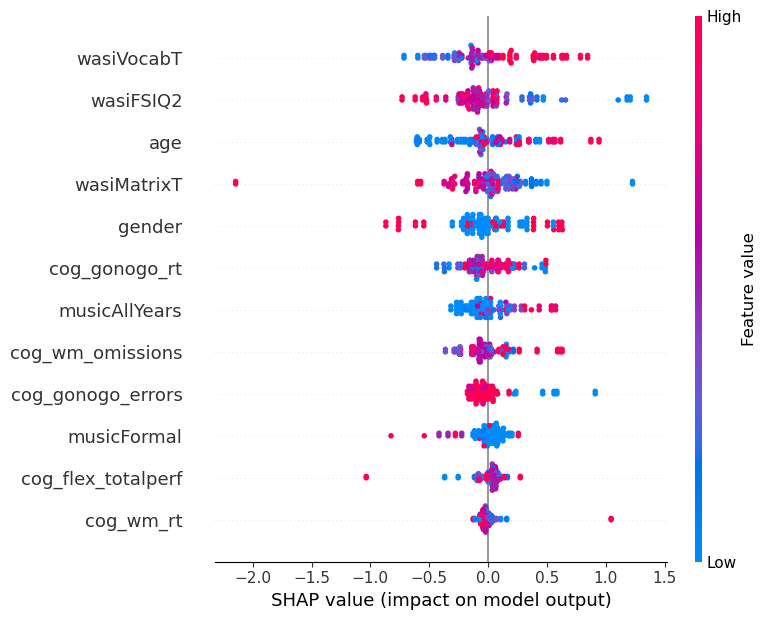

In [72]:
model = MLP(12, 1)
model.load_state_dict(torch.load('results/factor_v1/deep_model_1.mdl'))



df_to_run = pd.read_csv('../data/deep_factor_test_retest_imputed_all_standardized.csv')
data_arr = df_to_run.iloc[:, 2:].to_numpy()
X = data_arr[:, :12]
feature_names = df_to_run.iloc[:, 2:14].columns
X_torch = torch.from_numpy(X).float()



shap.DeepExplainer(model=model, data=X_torch)
shap.initjs() 
explainer = shap.DeepExplainer(model=model, data=X_torch)
shap_values = explainer.shap_values(X_torch)
shap.summary_plot(shap_values, features=X_torch, feature_names=feature_names, title='factor 1') 

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead


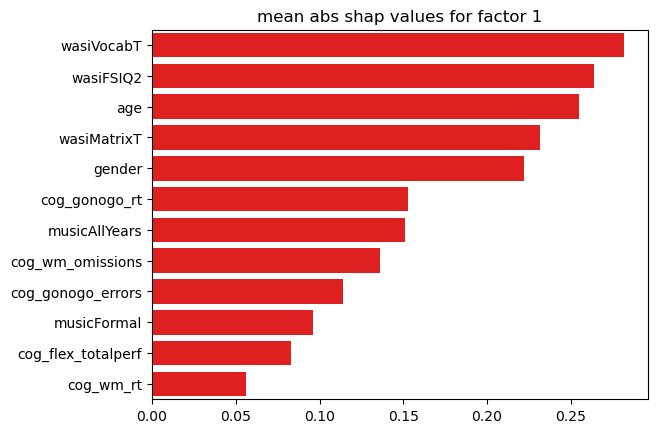

In [73]:
mean_val = np.mean(np.abs(shap_values), axis=0)
g = sns.barplot(y=feature_names,
                x=mean_val, palette=['r'],
                order=feature_names[np.argsort(-mean_val)]
               )
g.set_title('mean abs shap values for factor 1')

name = 'mean_abs_shap_fac1'
g.figure.savefig("results/" + name + ".png") 

Text(0.5, 0.98, 'Factor 1')

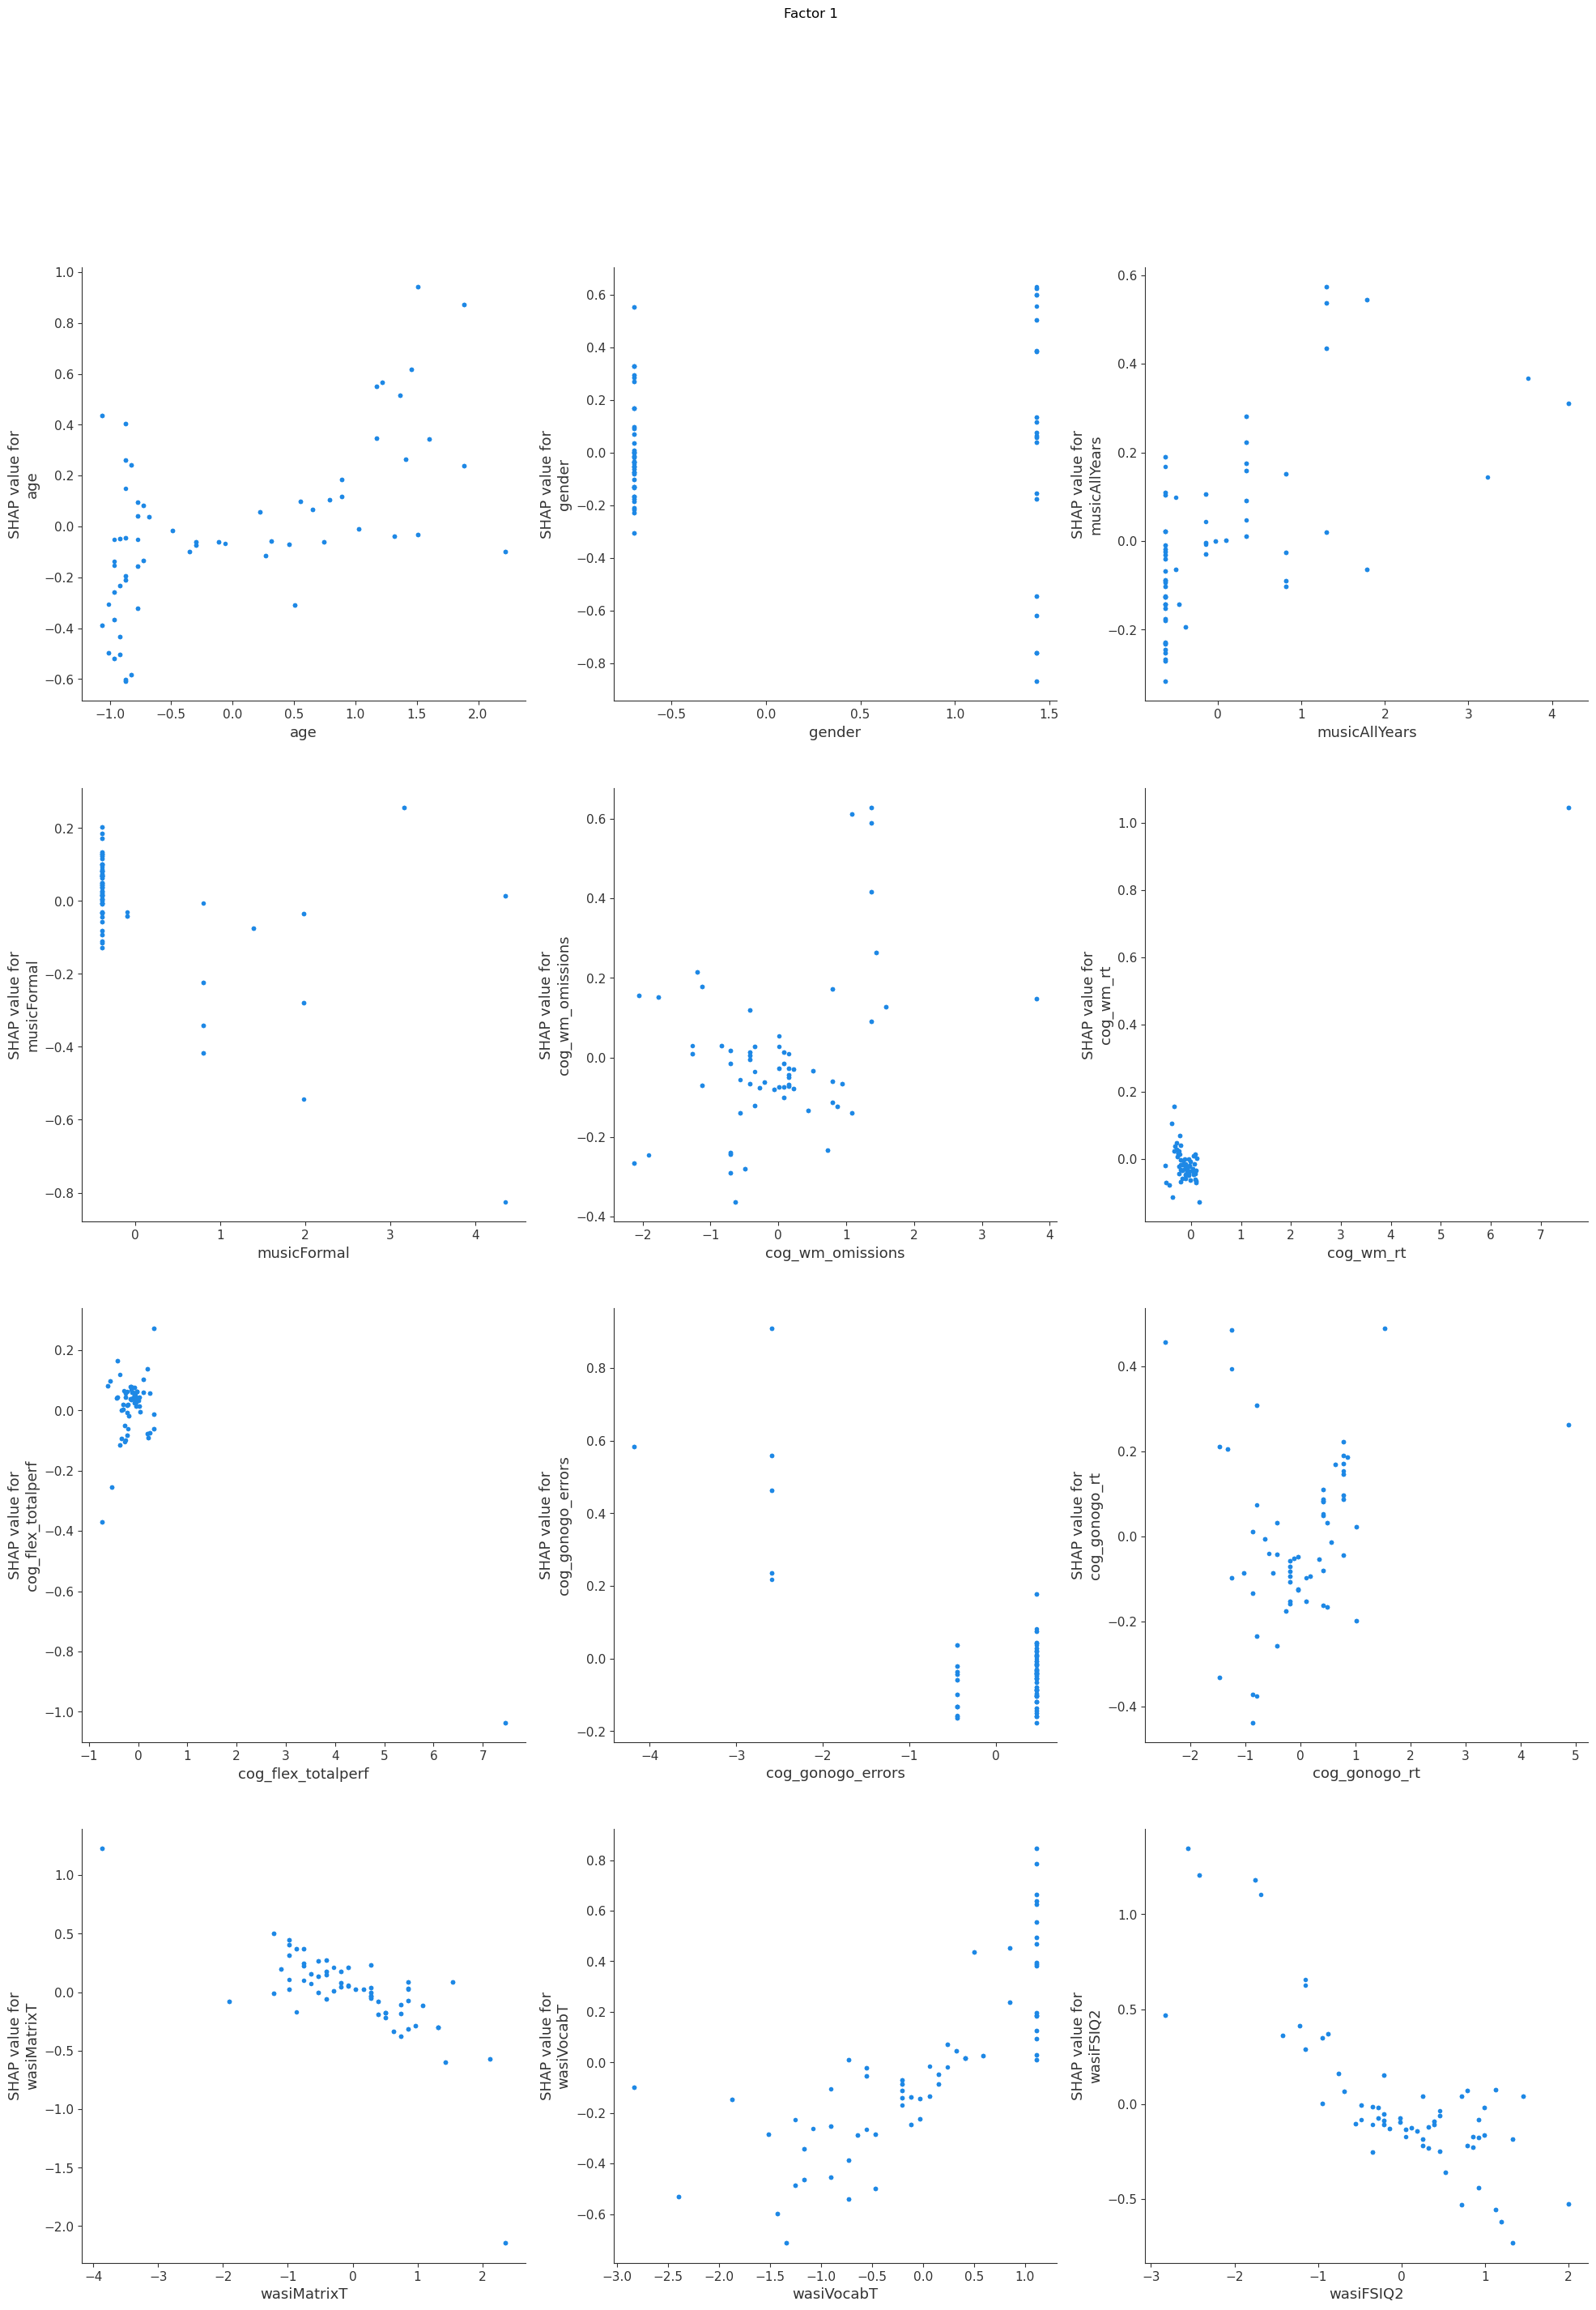

In [74]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(24,32))

shap.dependence_plot(ind=0, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 0], show=False) 

shap.dependence_plot(ind=1, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 1], show=False) 

shap.dependence_plot(ind=2, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 2], show=False) 

shap.dependence_plot(ind=3, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 0], show=False) 

shap.dependence_plot(ind=4, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 1], show=False) 

shap.dependence_plot(ind=5, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 2], show=False) 

shap.dependence_plot(ind=6, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 0], show=False) 

shap.dependence_plot(ind=7, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 1], show=False) 

shap.dependence_plot(ind=8, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 2], show=False) 

shap.dependence_plot(ind=9, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 0], show=False) 

shap.dependence_plot(ind=10, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 1], show=False) 

shap.dependence_plot(ind=11, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 2], show=False) 


fig.suptitle('Factor 1')

# Factor 2

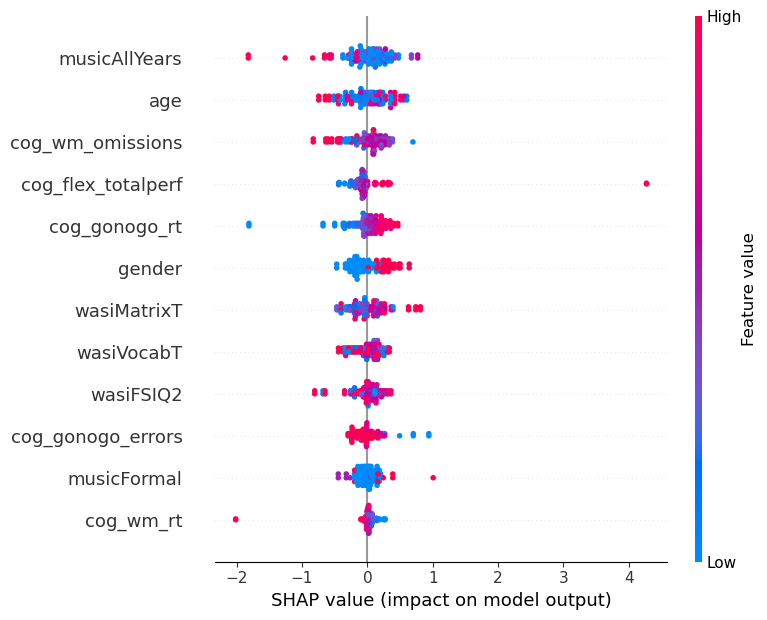

In [75]:
model = MLP(12, 1)
model.load_state_dict(torch.load('results/factor_v1/deep_model_2.mdl'))



df_to_run = pd.read_csv('../data/deep_factor_test_retest_imputed_all_standardized.csv')
data_arr = df_to_run.iloc[:, 2:].to_numpy()
X = data_arr[:, :12]
feature_names = df_to_run.iloc[:, 2:14].columns
X_torch = torch.from_numpy(X).float()



shap.DeepExplainer(model=model, data=X_torch)
shap.initjs() 
explainer = shap.DeepExplainer(model=model, data=X_torch)
shap_values = explainer.shap_values(X_torch)
shap.summary_plot(shap_values, features=X_torch, feature_names=feature_names, title='factor 2') 

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead


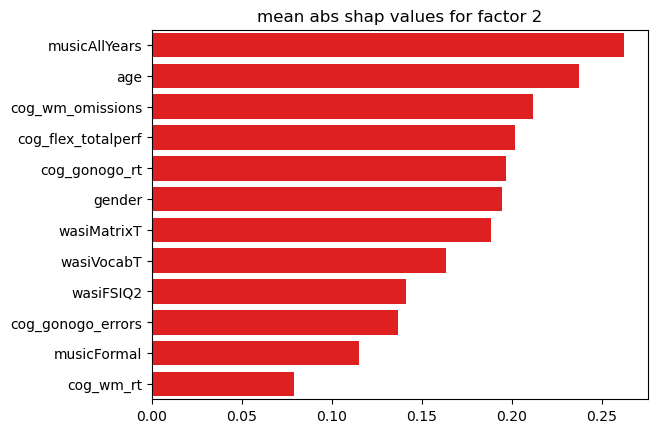

In [76]:
mean_val = np.mean(np.abs(shap_values), axis=0)
g = sns.barplot(y=feature_names,
                x=mean_val, palette=['r'],
                order=feature_names[np.argsort(-mean_val)]
               )
g.set_title('mean abs shap values for factor 2')

name = 'mean_abs_shap_fac2'
g.figure.savefig("results/" + name + ".png") 

Text(0.5, 0.98, 'Factor 2')

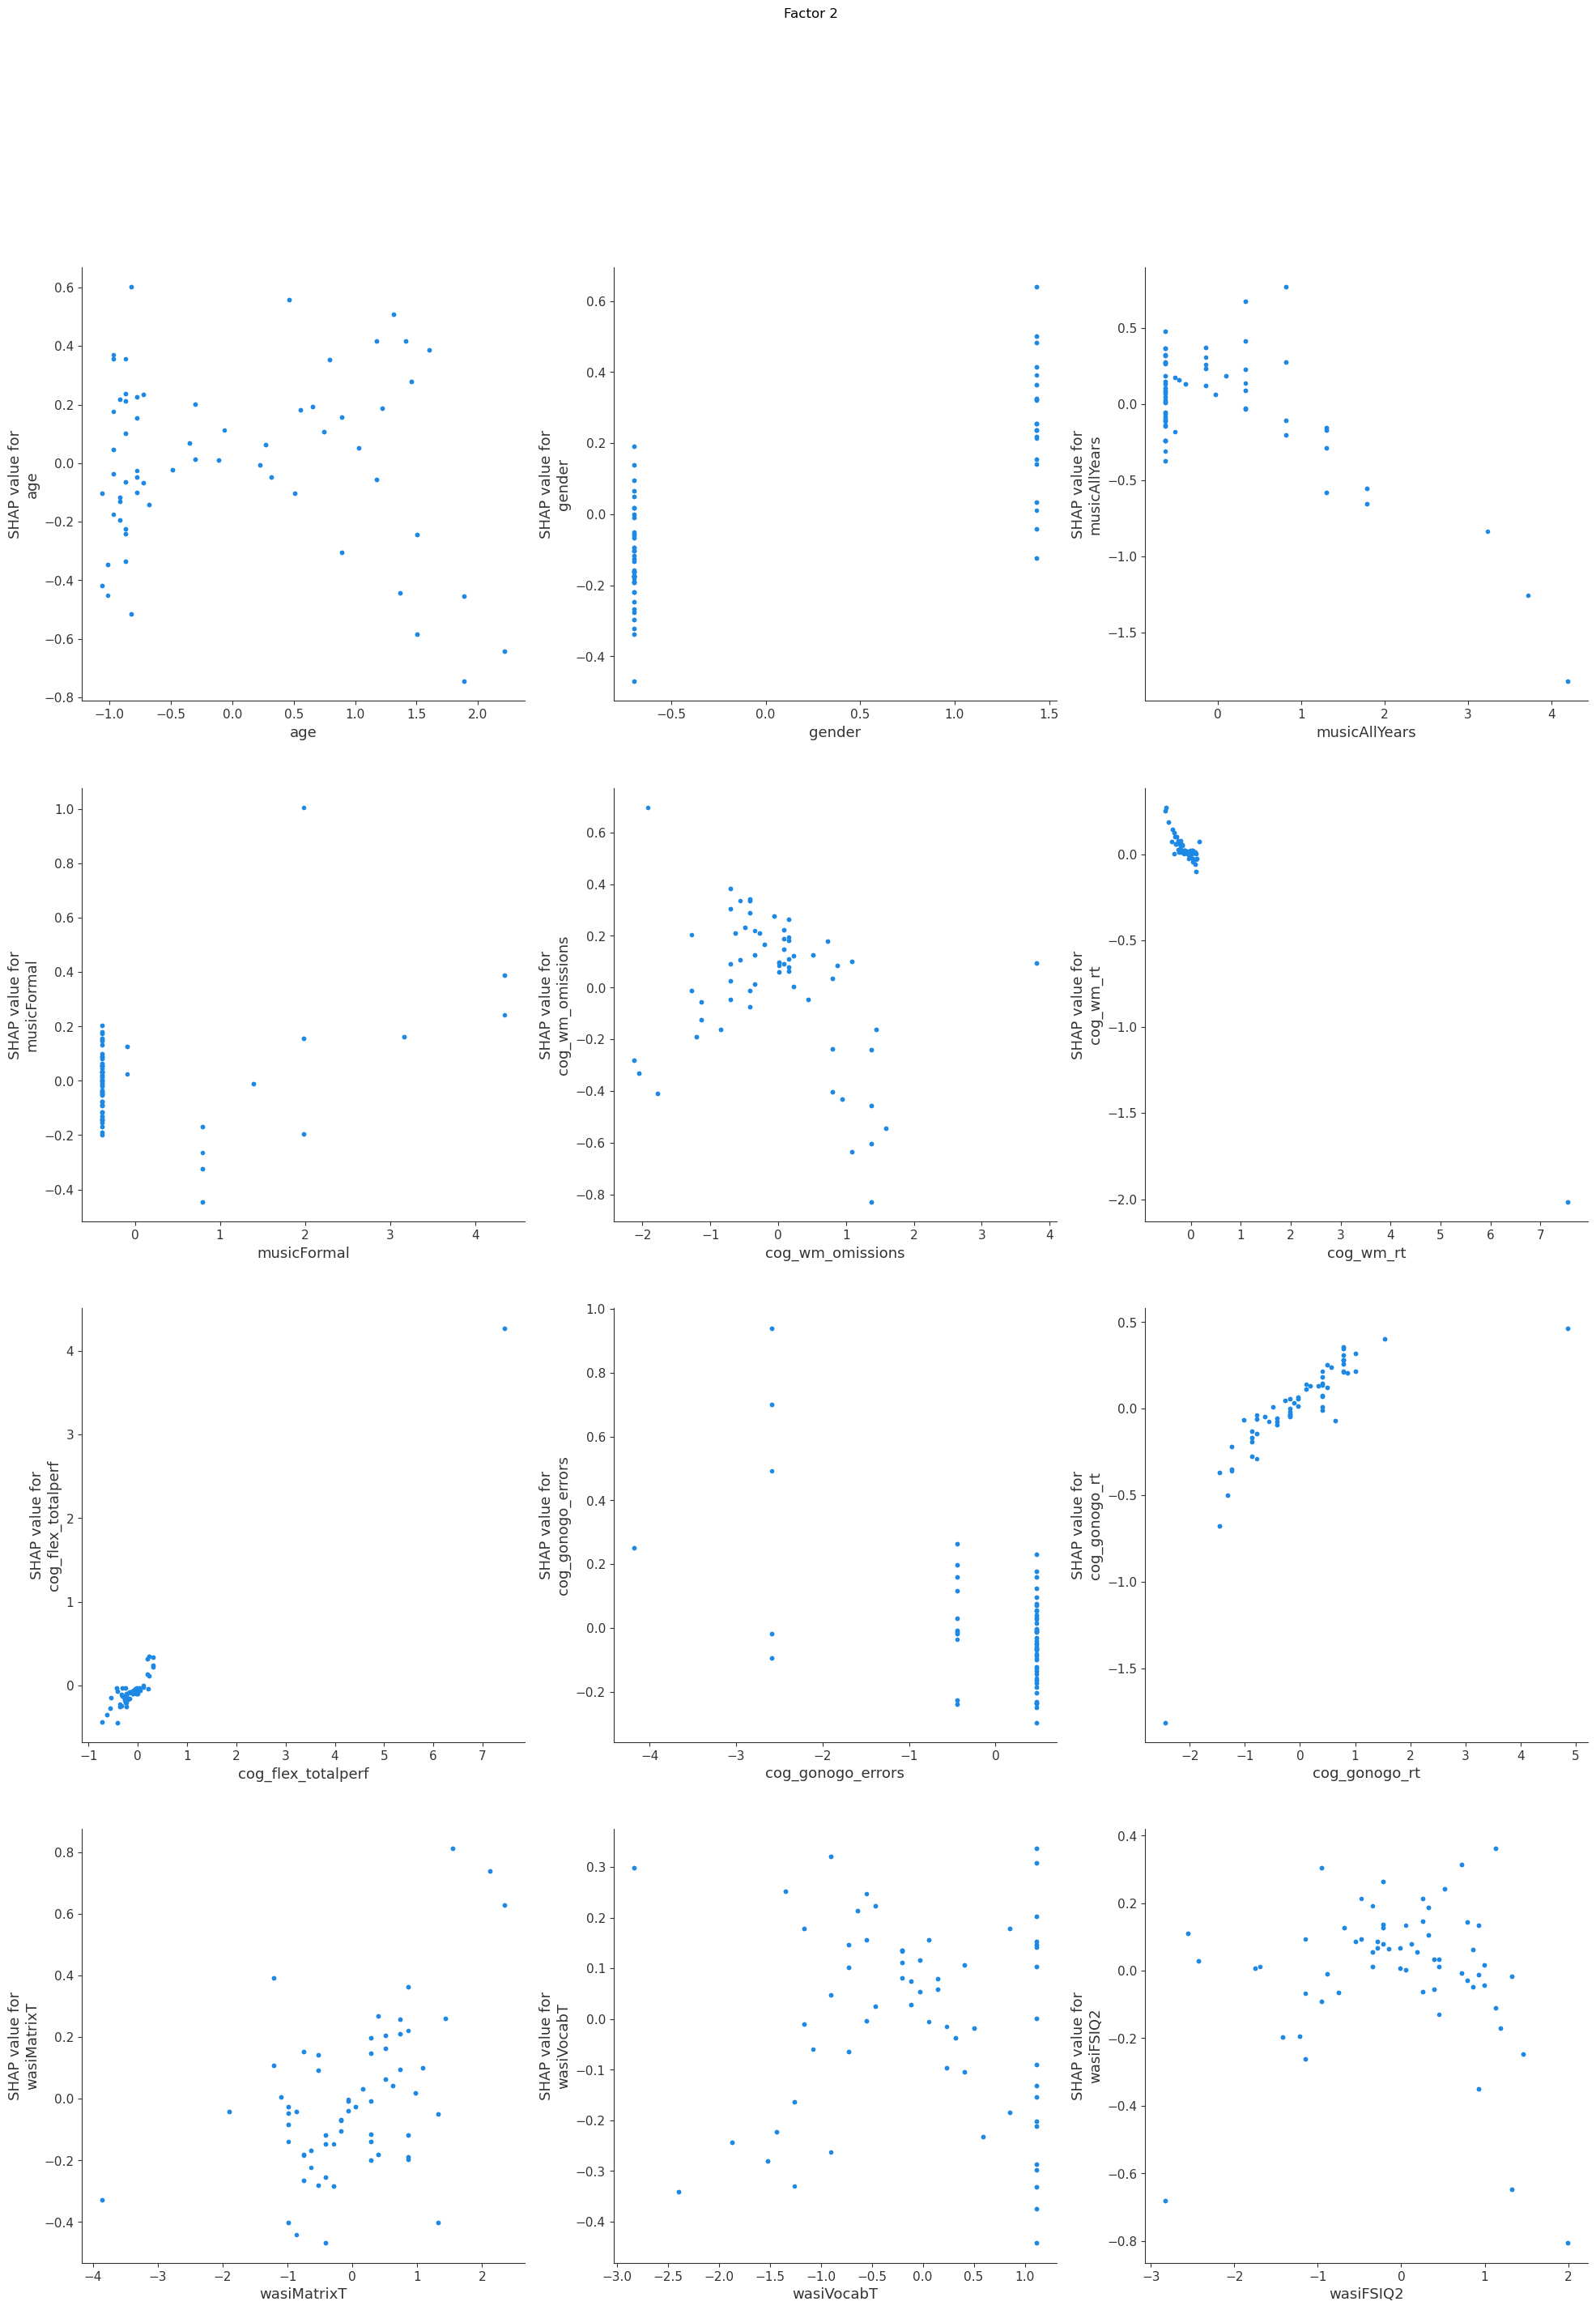

In [77]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(24,32))

shap.dependence_plot(ind=0, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 0], show=False) 

shap.dependence_plot(ind=1, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 1], show=False) 

shap.dependence_plot(ind=2, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 2], show=False) 

shap.dependence_plot(ind=3, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 0], show=False) 

shap.dependence_plot(ind=4, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 1], show=False) 

shap.dependence_plot(ind=5, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 2], show=False) 

shap.dependence_plot(ind=6, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 0], show=False) 

shap.dependence_plot(ind=7, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 1], show=False) 

shap.dependence_plot(ind=8, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 2], show=False) 

shap.dependence_plot(ind=9, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 0], show=False) 

shap.dependence_plot(ind=10, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 1], show=False) 

shap.dependence_plot(ind=11, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 2], show=False) 


fig.suptitle('Factor 2')

# Factor 3

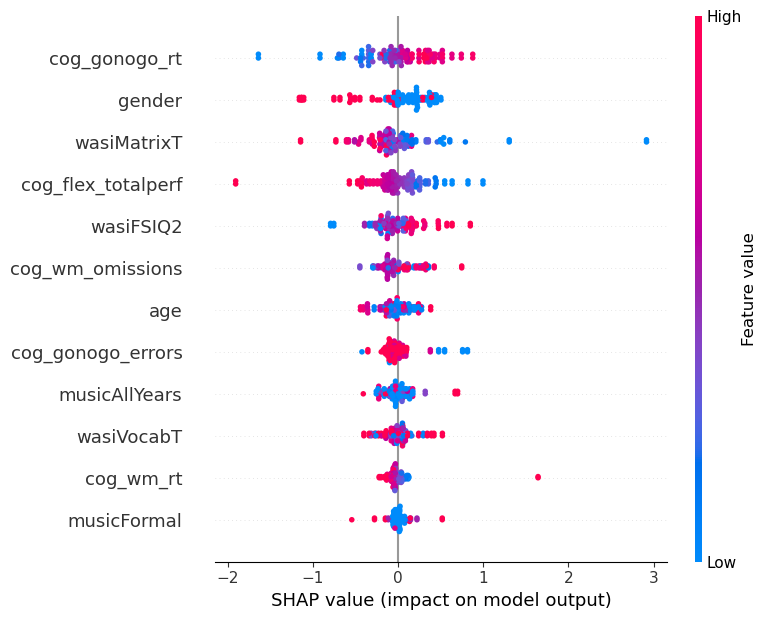

In [78]:
model = MLP(12, 1)
model.load_state_dict(torch.load('results/factor_v1/deep_model_3.mdl'))



df_to_run = pd.read_csv('../data/deep_factor_test_retest_imputed_all_standardized.csv')
data_arr = df_to_run.iloc[:, 2:].to_numpy()
X = data_arr[:, :12]
feature_names = df_to_run.iloc[:, 2:14].columns
X_torch = torch.from_numpy(X).float()



shap.DeepExplainer(model=model, data=X_torch)
shap.initjs() 
explainer = shap.DeepExplainer(model=model, data=X_torch)
shap_values = explainer.shap_values(X_torch)
shap.summary_plot(shap_values, features=X_torch, feature_names=feature_names, title='factor 3') 

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead


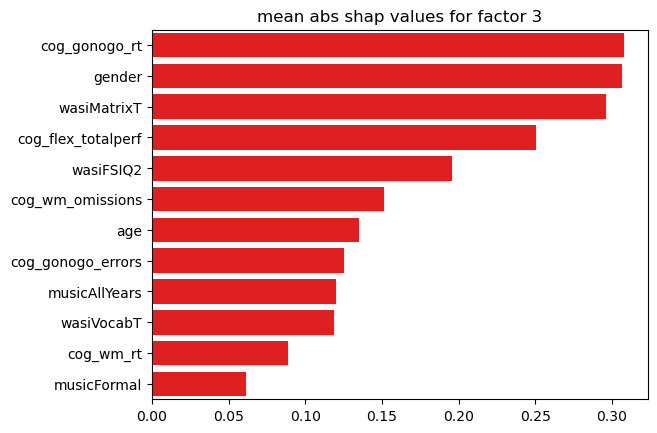

In [79]:
mean_val = np.mean(np.abs(shap_values), axis=0)
g = sns.barplot(y=feature_names,
                x=mean_val, palette=['r'],
                order=feature_names[np.argsort(-mean_val)]
               )
g.set_title('mean abs shap values for factor 3')

name = 'mean_abs_shap_fac3'
g.figure.savefig("results/" + name + ".png") 

Text(0.5, 0.98, 'Factor 3')

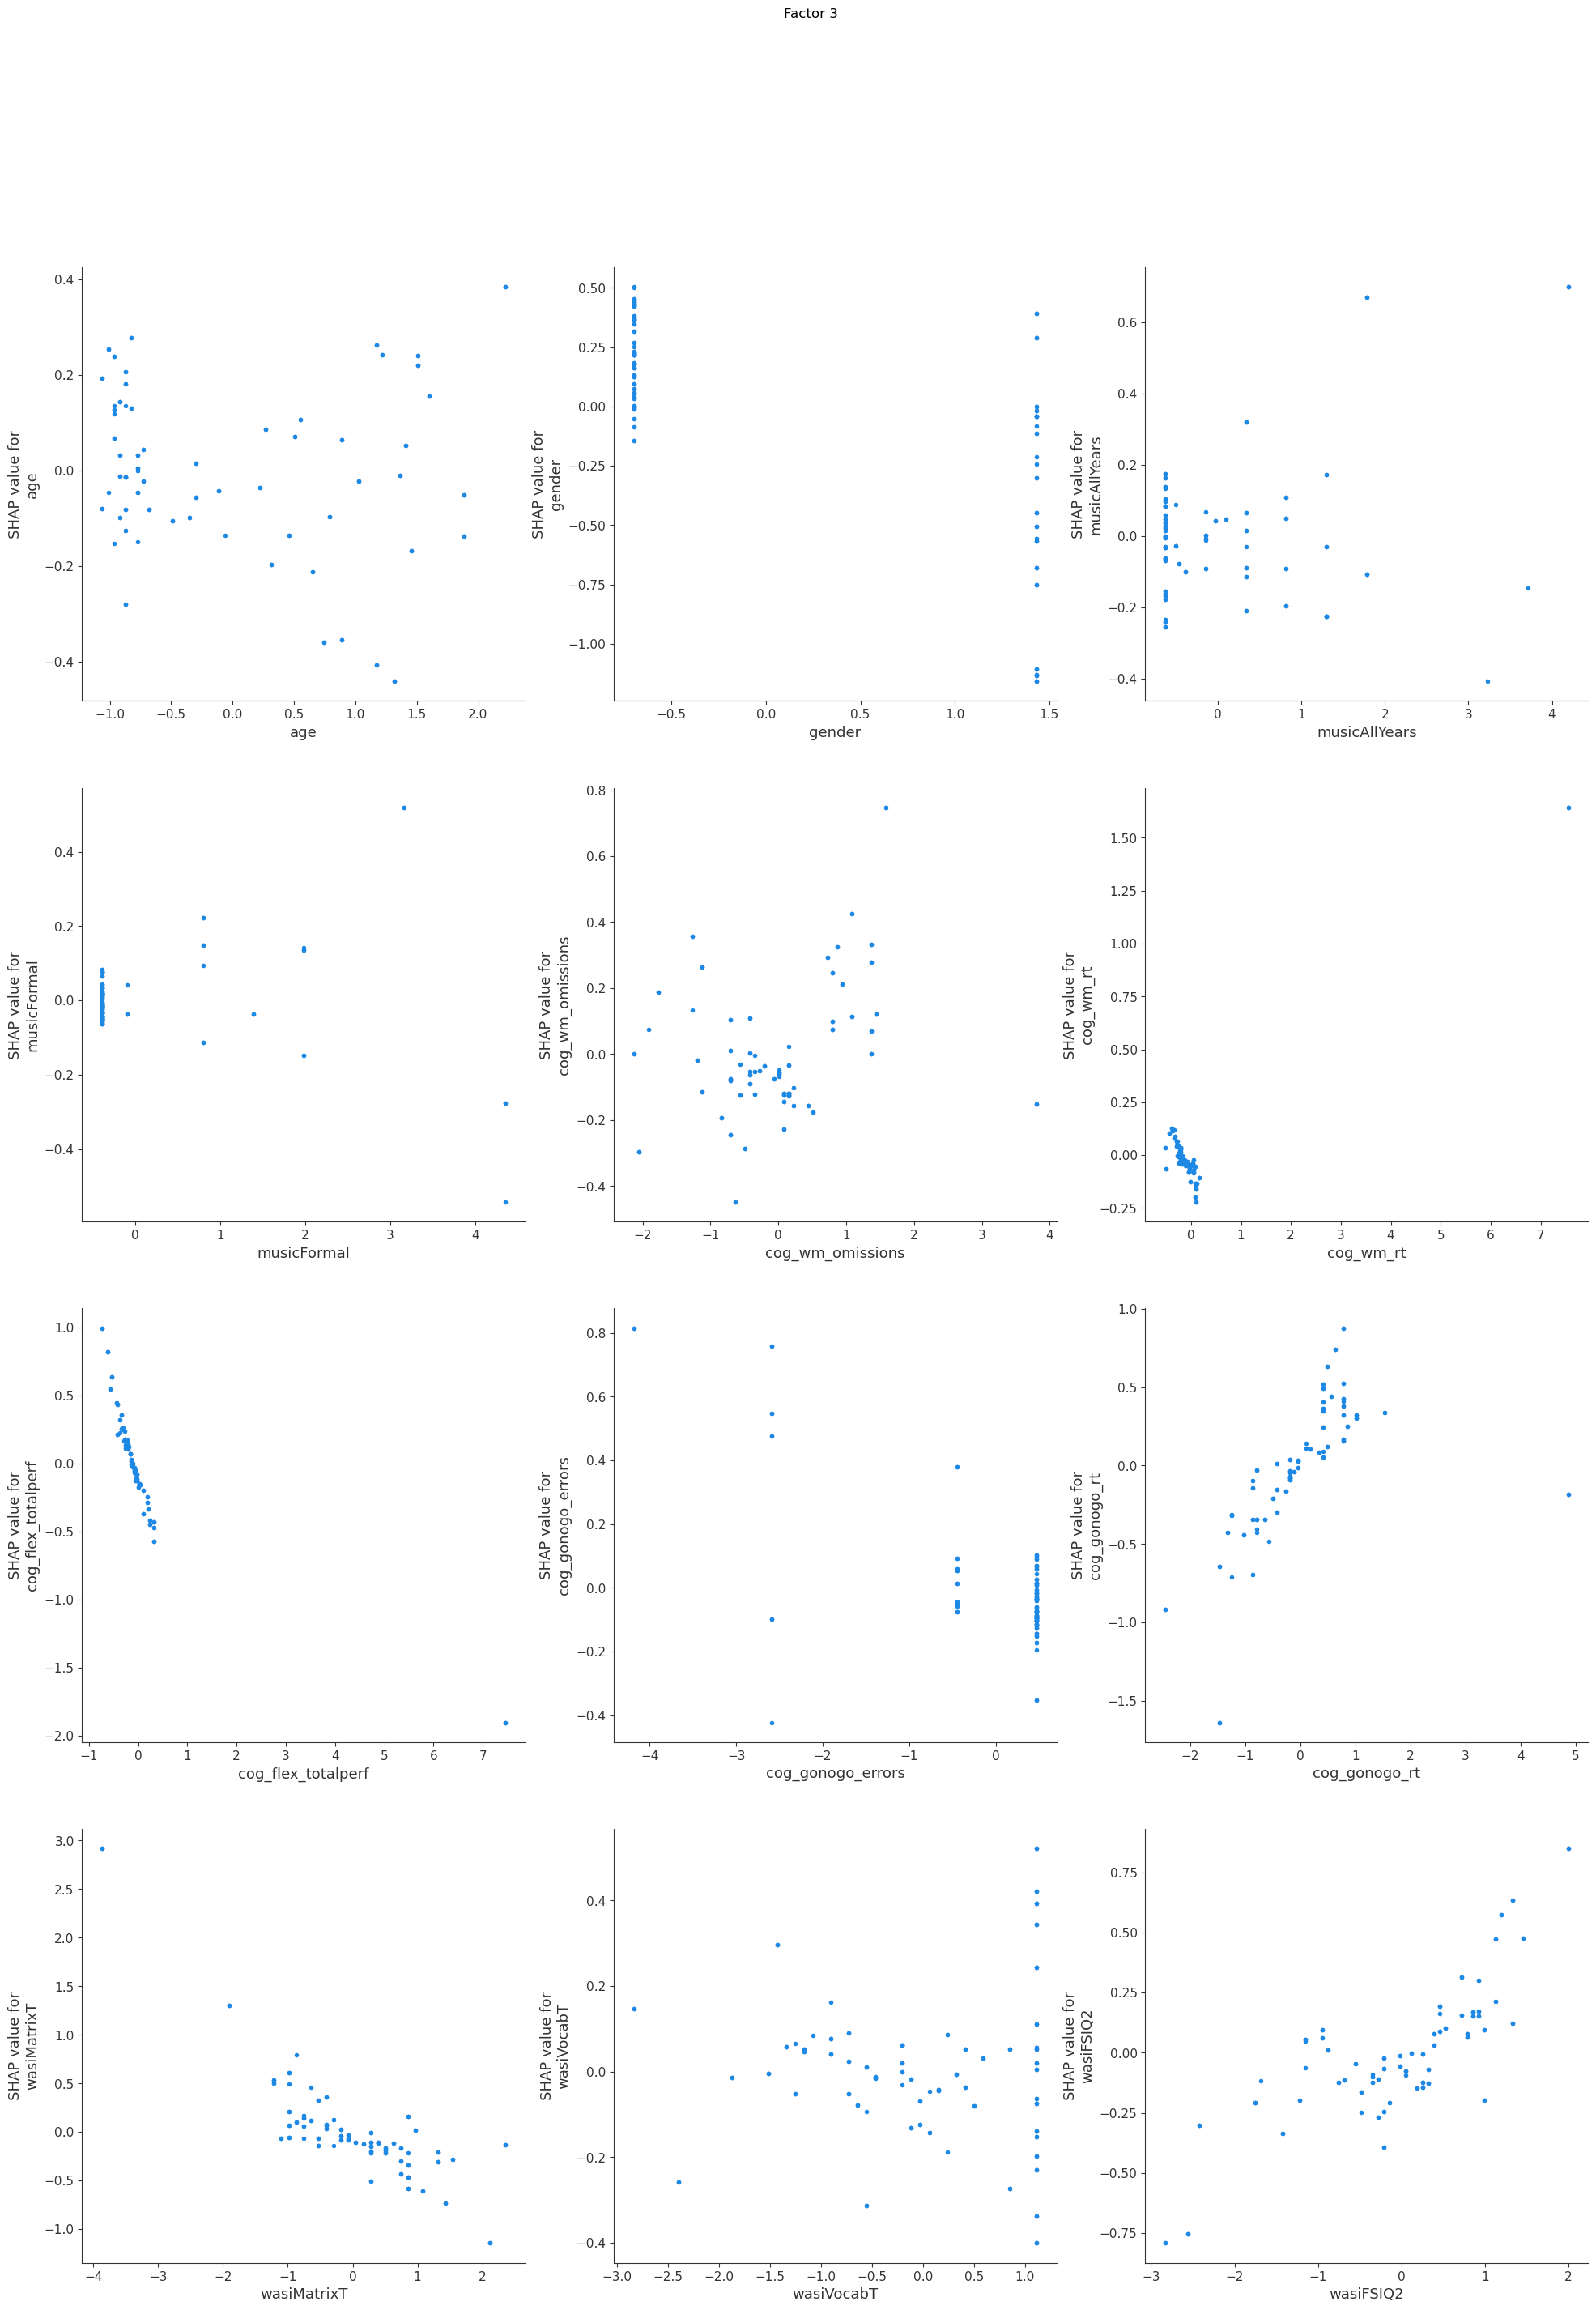

In [80]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(24,32))

shap.dependence_plot(ind=0, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 0], show=False) 

shap.dependence_plot(ind=1, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 1], show=False) 

shap.dependence_plot(ind=2, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 2], show=False) 

shap.dependence_plot(ind=3, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 0], show=False) 

shap.dependence_plot(ind=4, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 1], show=False) 

shap.dependence_plot(ind=5, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 2], show=False) 

shap.dependence_plot(ind=6, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 0], show=False) 

shap.dependence_plot(ind=7, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 1], show=False) 

shap.dependence_plot(ind=8, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 2], show=False) 

shap.dependence_plot(ind=9, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 0], show=False) 

shap.dependence_plot(ind=10, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 1], show=False) 

shap.dependence_plot(ind=11, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 2], show=False) 


fig.suptitle('Factor 3')

# Factor 4

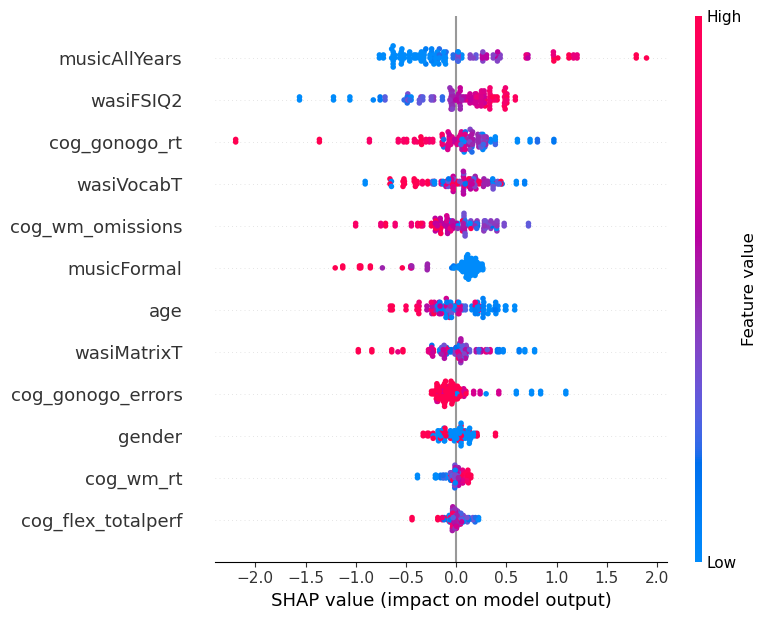

In [81]:
model = MLP(12, 1)
model.load_state_dict(torch.load('results/factor_v1/deep_model_4.mdl'))



df_to_run = pd.read_csv('../data/deep_factor_test_retest_imputed_all_standardized.csv')
data_arr = df_to_run.iloc[:, 2:].to_numpy()
X = data_arr[:, :12]
feature_names = df_to_run.iloc[:, 2:14].columns
X_torch = torch.from_numpy(X).float()



shap.DeepExplainer(model=model, data=X_torch)
explainer = shap.DeepExplainer(model=model, data=X_torch)
shap_values = explainer.shap_values(X_torch)
shap.summary_plot(shap_values, features=X_torch, feature_names=feature_names, title='factor 4') 

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead


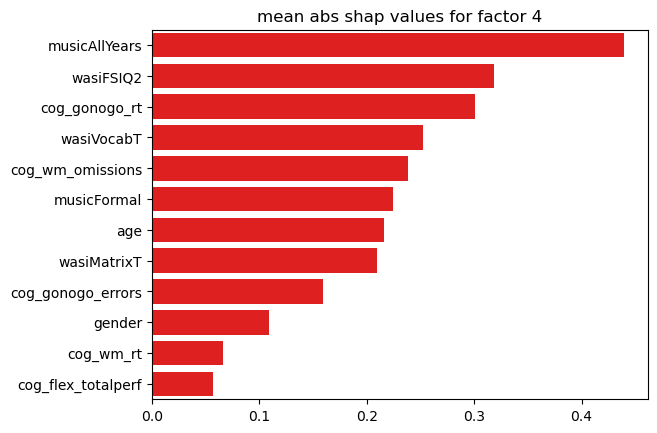

In [83]:
mean_val = np.mean(np.abs(shap_values), axis=0)
g = sns.barplot(y=feature_names,
                x=mean_val, palette=['r'],
                order=feature_names[np.argsort(-mean_val)]
               )
g.set_title('mean abs shap values for factor 4')

name = 'mean_abs_shap_fac4'
g.figure.savefig("results/" + name + ".png") 

Text(0.5, 0.98, 'Factor 4')

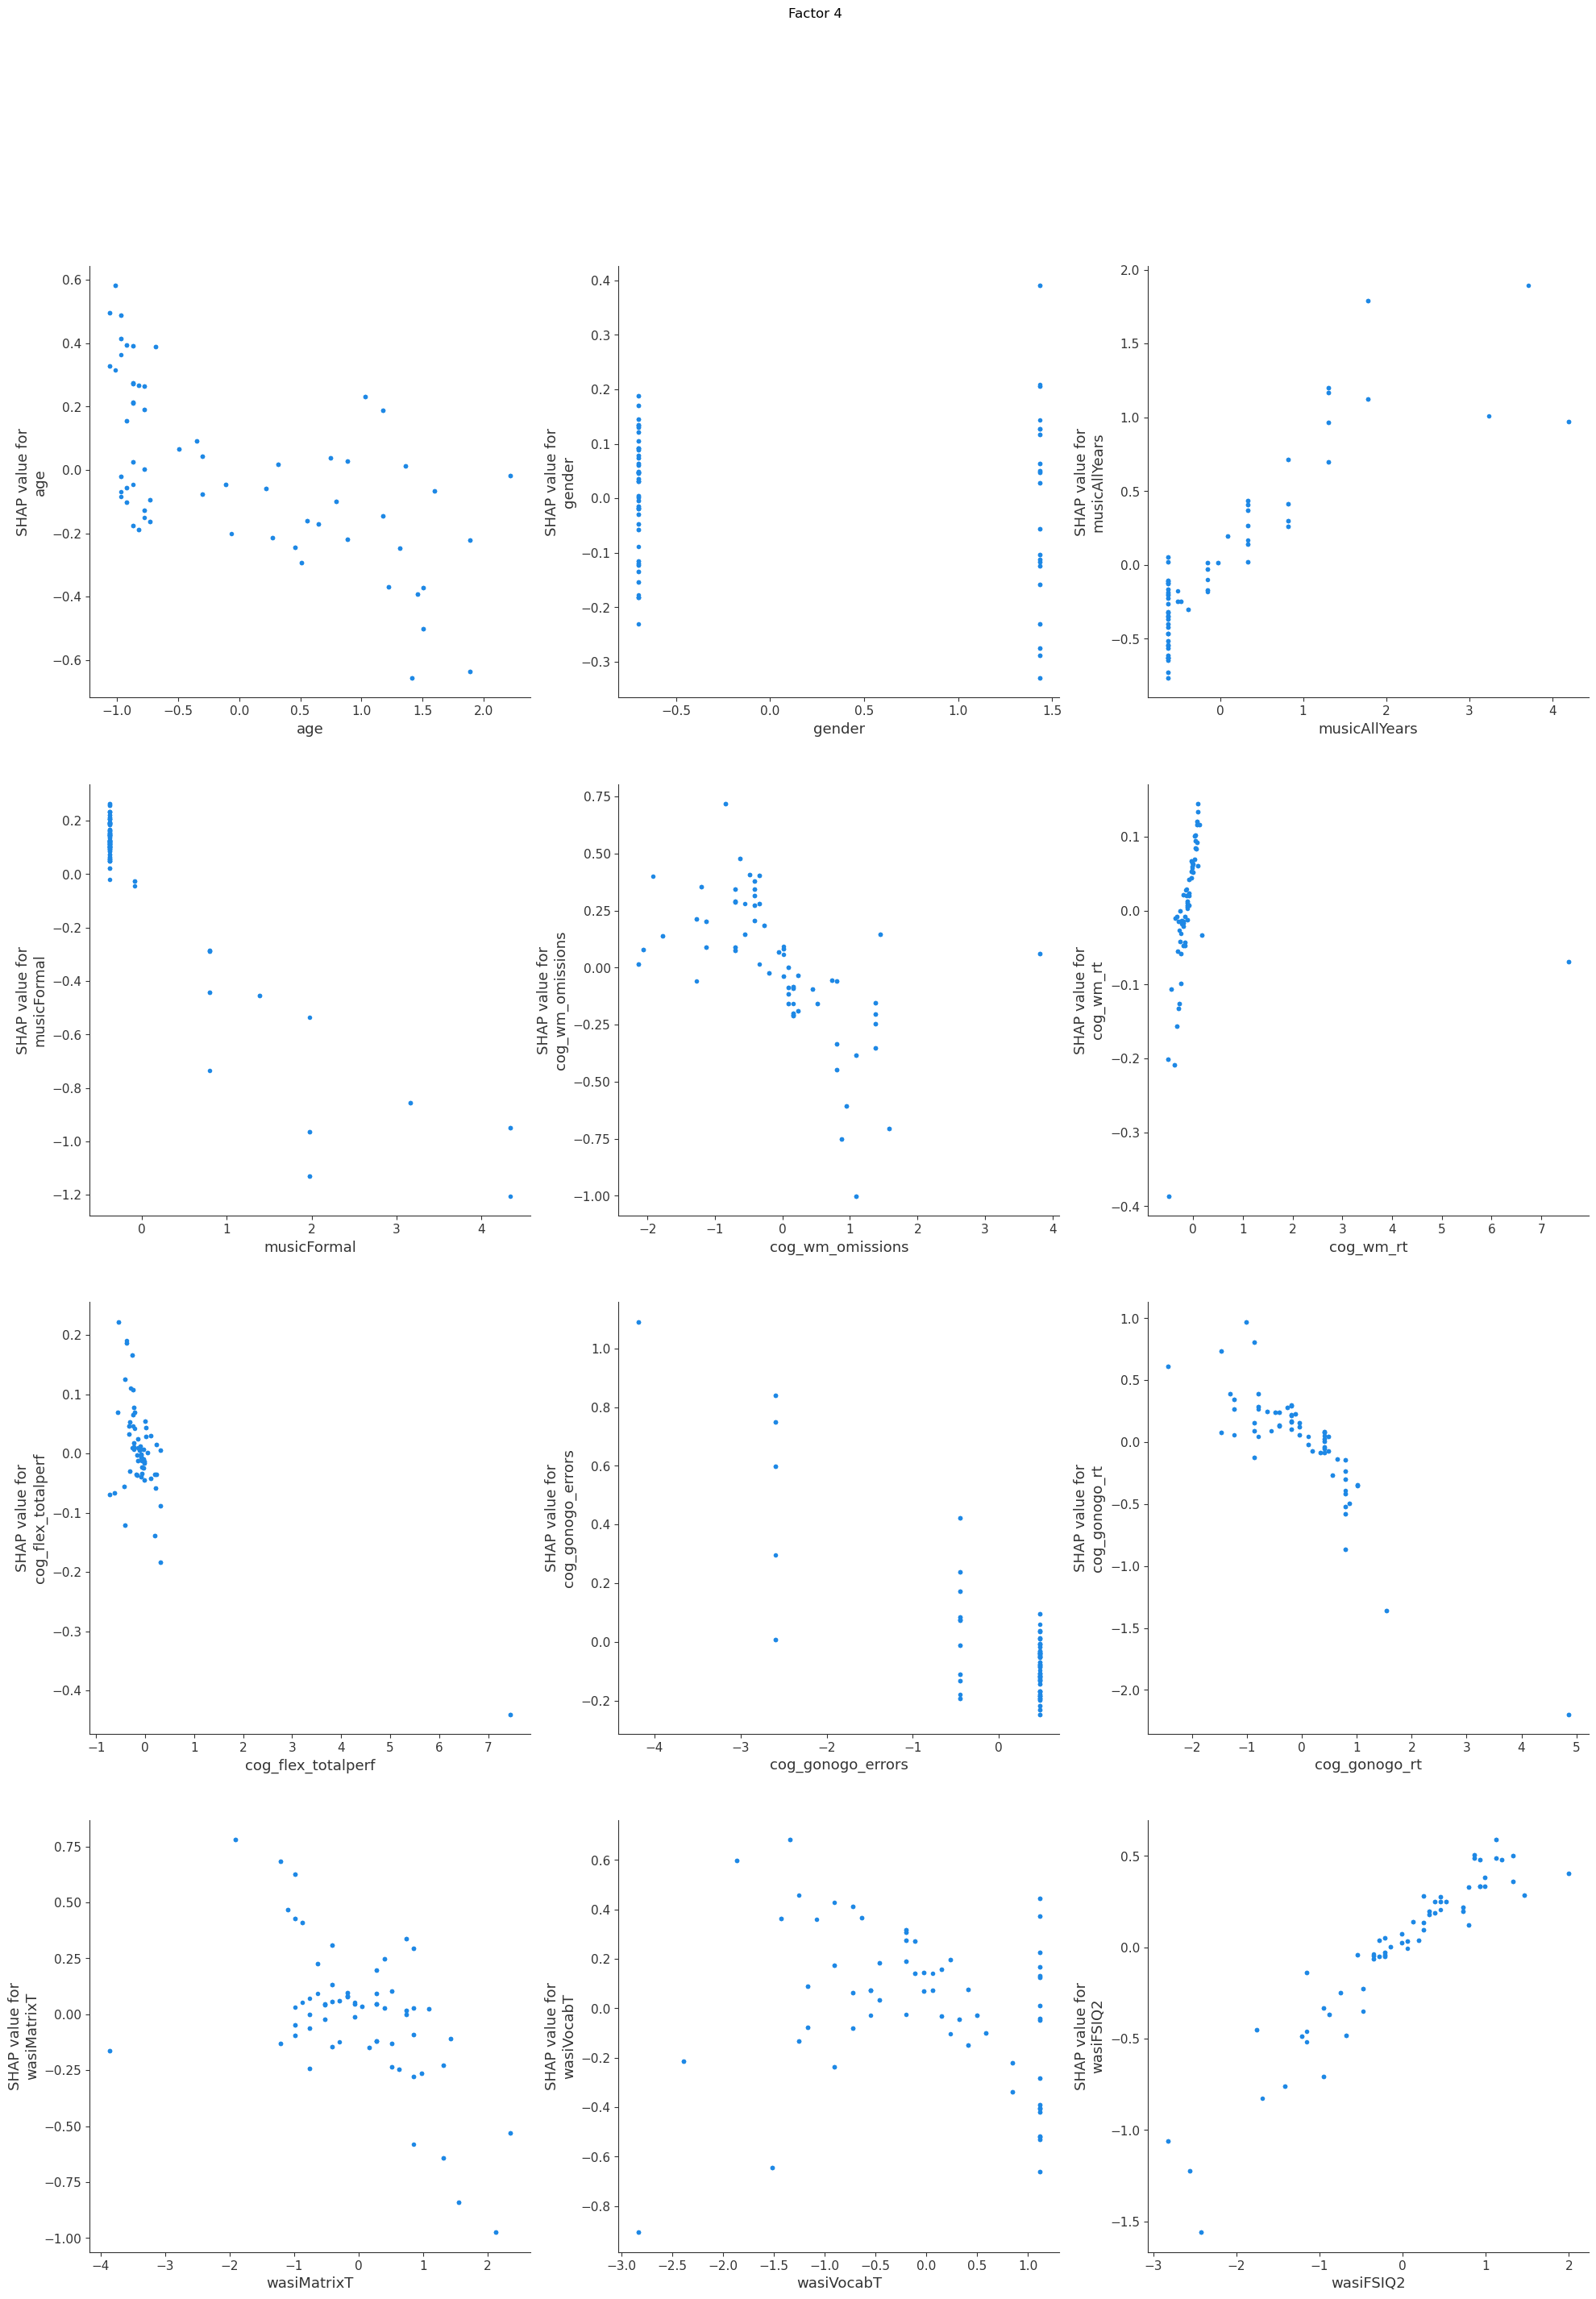

In [84]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(24,32))

shap.dependence_plot(ind=0, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 0], show=False) 

shap.dependence_plot(ind=1, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 1], show=False) 

shap.dependence_plot(ind=2, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[0, 2], show=False) 

shap.dependence_plot(ind=3, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 0], show=False) 

shap.dependence_plot(ind=4, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 1], show=False) 

shap.dependence_plot(ind=5, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[1, 2], show=False) 

shap.dependence_plot(ind=6, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 0], show=False) 

shap.dependence_plot(ind=7, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 1], show=False) 

shap.dependence_plot(ind=8, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[2, 2], show=False) 

shap.dependence_plot(ind=9, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 0], show=False) 

shap.dependence_plot(ind=10, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 1], show=False) 

shap.dependence_plot(ind=11, shap_values=shap_values, features=X, 
                     feature_names=feature_names, interaction_index=None, ax=axes[3, 2], show=False) 


fig.suptitle('Factor 4')